# EDA - Default of Credit Card Clients

This notebook contains the **exploratory data analysis (EDA) and classification modeling** performed on the **Default of Credit Card Clients** dataset.  

Dataset source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

---

## Goal

The goal of this project is to **analyze and model credit card default payments**, including:  
1. **Exploratory Data Analysis (EDA)** – understand data distribution, patterns, and correlations.  
2. **Feature Engineering** – create, transform, or select features for better predictive performance.  
3. **Model Training** – build classification models to predict default payments.  
4. **Model Evaluation** – assess model performance using appropriate metrics and validate results.  


---

## Overview

This research focuses on the **case of customers' default payments in Taiwan** and compares the predictive accuracy of the probability of default among six data mining methods.

### Dataset Characteristics
- **Type:** Multivariate  
- **Subject Area:** Business  
- **Associated Task:** Classification  
- **Feature Type:** Integer, Real  
- **Instances:** 30,000  
- **Features:** 23  

### Analysis Includes
- Basic data information
- Class distribution
- Numeric summaries
- Histograms
- Correlation matrices
- Boxplots for key features
- Sampled scatter matrix

In [1]:
# Core libraries
import re

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & feature engineering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate

# Metrics & evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, confusion_matrix, 
                             classification_report)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier



import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../../../../resource/source/UCI_Credit_Card.csv")
# read dataset

In [3]:
print("Rows X Columns:",df.shape)
print("Source Columns:",df.columns.tolist())
df.head(2)

Rows X Columns: (30000, 25)
Source Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1


In [4]:
df.drop('ID',axis=1,inplace=True)
# remove ID columns

In [5]:
df.rename(columns={'PAY_0':'PAY_1'}, inplace=True)
# rename PAY_0 to be aligned in format

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_1                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [8]:
# high level dataset details
pd.DataFrame(
    {
    "data_type": df.dtypes.astype(str),
     "n_unique": df.nunique(),
      "missing_values": df.isna().sum()
    })

,data_type,n_unique,missing_values
LIMIT_BAL,float64,81,0
SEX,int64,2,0
EDUCATION,int64,7,0
MARRIAGE,int64,4,0
AGE,int64,56,0
PAY_1,int64,11,0
PAY_2,int64,11,0
PAY_3,int64,11,0
PAY_4,int64,11,0
PAY_5,int64,10,0


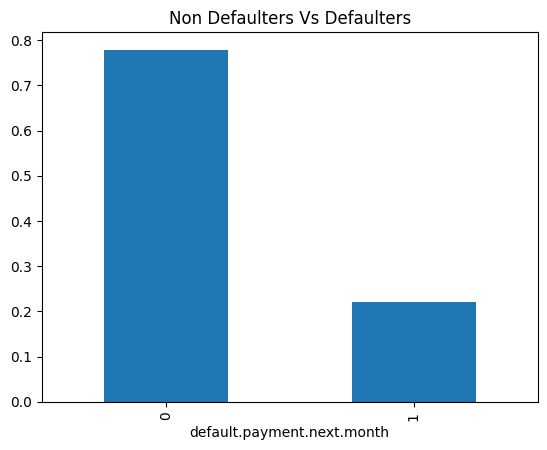

In [9]:
df['default.payment.next.month'].value_counts(normalize=True).plot.bar()
plt.title('Non Defaulters Vs Defaulters')
plt.show()
#target distribution

In [10]:
target = "default.payment.next.month"
# target column value assign

In [11]:
# Count of target values
counts = df[target].value_counts()
print("Counts:", counts)

Counts: default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


In [12]:
# Percentage of each value
percentages = df[target].value_counts(normalize=True) * 100
print("Percentages:", percentages)

Percentages: default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


#### Default = 22%
#### Imbalanced Data

##### SEX EDUCATION MARRIAGE
    1. SEX: Gender (1=male, 2=female)
    2. EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
    3. MARRIAGE: Marital status (1=married, 2=single, 3=others)

In [13]:
df[['SEX','EDUCATION','MARRIAGE']].describe()

,SEX,EDUCATION,MARRIAGE
count,30000.000000,30000.000000,30000.000000
mean,1.603733,1.853133,1.551867
std,0.489129,0.790349,0.521970
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,2.000000,6.000000,3.000000


In [14]:
print(df['MARRIAGE'].unique())
print(df['MARRIAGE'].value_counts())

[1 2 3 0]
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [15]:
# Replacing 0 of marriage with 3(others)
df['MARRIAGE']=df['MARRIAGE'].replace({0:3})

In [16]:
print(df['EDUCATION'].unique())
print(df['EDUCATION'].value_counts())

[2 1 3 5 4 6 0]
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In [17]:
# Replacing 0,5,6 with 4
df['EDUCATION']=df['EDUCATION'].replace({0:4,5:4,6:4})

In [18]:
print(df['SEX'].unique())
print(df['SEX'].value_counts())

[2 1]
SEX
2    18112
1    11888
Name: count, dtype: int64


In [19]:
df['MARRIAGE']=df['MARRIAGE'].replace({1:'married',2:'single',3:'others'})
df['EDUCATION']=df['EDUCATION'].replace({1:'graduate school',2:'university',3:'high school',4:'others'})
df['SEX']=df['SEX'].replace({1:'male', 2:'female'})

In [20]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [21]:
def plot_categoric(cat_col):
    plt.title('{0} vs DEFAULT PROBABILITY'.format(cat_col))
    df.groupby(cat_col)[target].mean().plot.bar()
    plt.show()

# feature with target distrubition

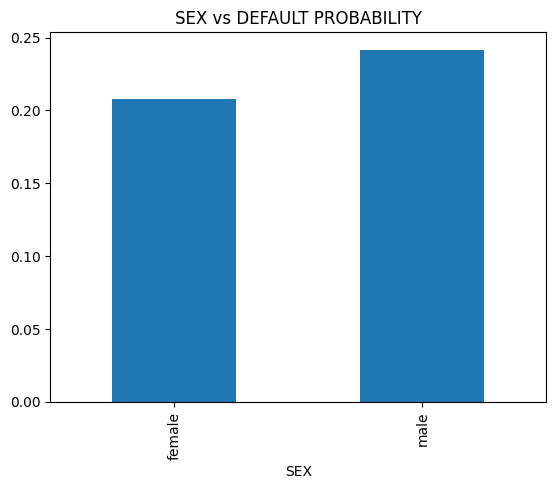

In [22]:
plot_categoric('SEX')

 ###  Men most like to be defaulters compared to Females

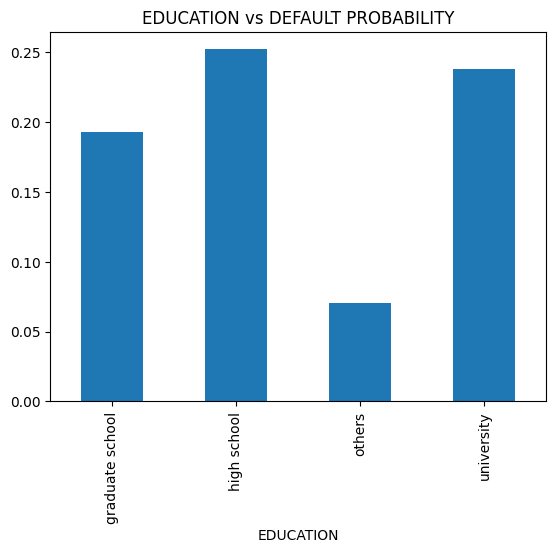

In [23]:
plot_categoric('EDUCATION')

### High School > University > graduates with respect to defaulters

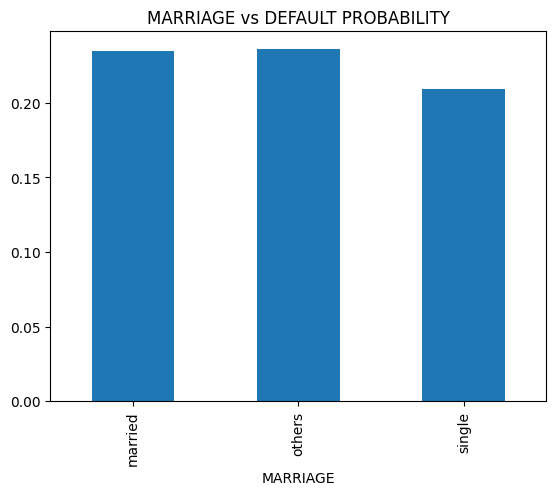

In [24]:
plot_categoric('MARRIAGE')

### Married & Others are most likely to be defaulter

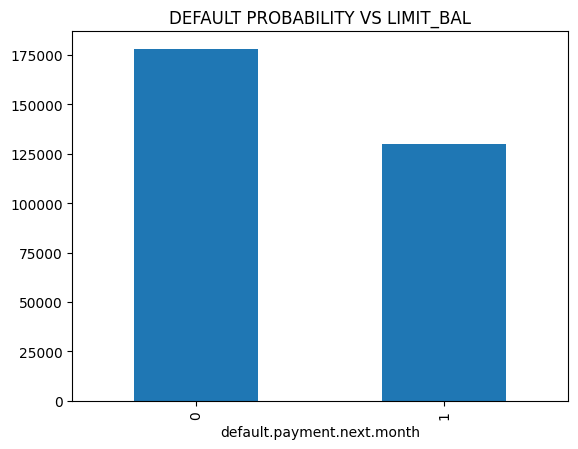

In [25]:
plt.title('DEFAULT PROBABILITY VS {0}'.format('LIMIT_BAL'))
df.groupby(target)['LIMIT_BAL'].mean().plot.bar()
plt.show()

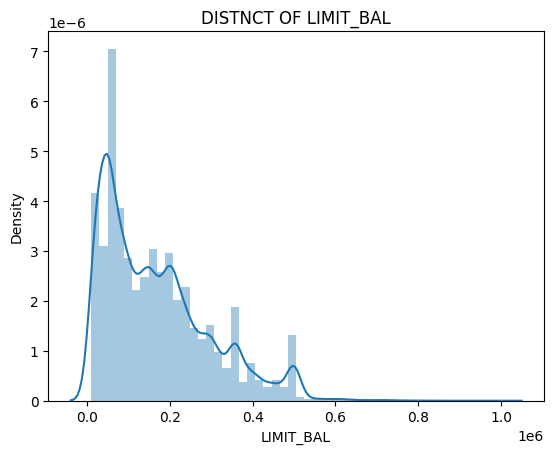

In [26]:
sns.distplot(df['LIMIT_BAL'])
plt.title('DISTNCT OF LIMIT_BAL')
plt.show()

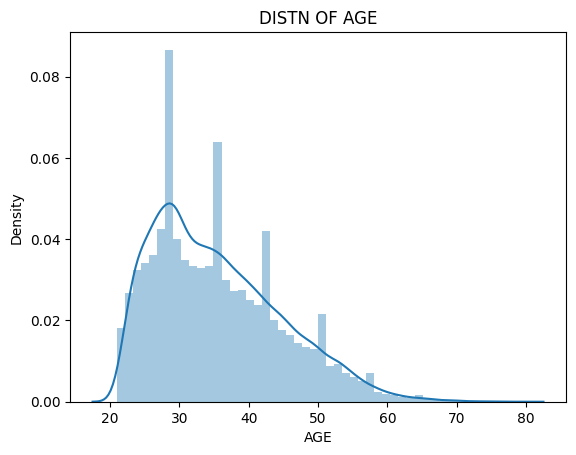

In [27]:
sns.distplot(df['AGE'])
plt.title('DISTN OF AGE')
plt.show()

# ANALYSING NUMERIC FEATURES FOR OUTLIERS

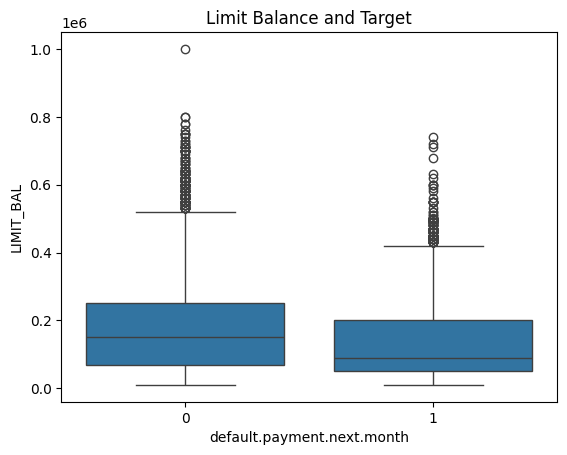

In [28]:
sns.boxplot(x=df[target],y=df['LIMIT_BAL'],data=df)
plt.title('Limit Balance and Target')
plt.show()

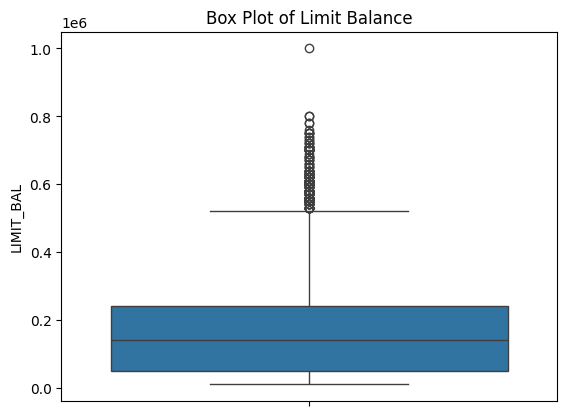

In [29]:
sns.boxplot(df['LIMIT_BAL'])
plt.title('Box Plot of Limit Balance')
plt.show()

In [30]:
df['LIMIT_BAL'].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [31]:
df.loc[df['LIMIT_BAL']>=df['LIMIT_BAL'].quantile(0.95),'LIMIT_BAL']=df['LIMIT_BAL'].quantile(0.95)
# percentile-based capping

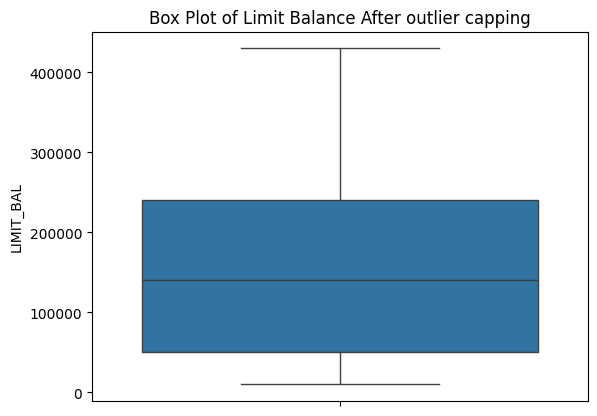

In [32]:
sns.boxplot(df['LIMIT_BAL'])
plt.title('Box Plot of Limit Balance After outlier capping')
plt.show()

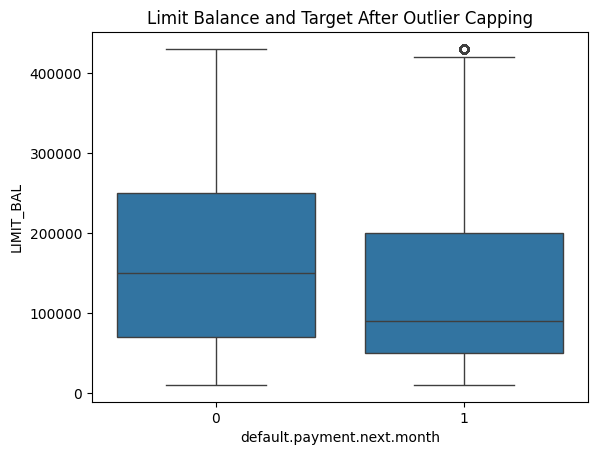

In [33]:
sns.boxplot(x=df[target],y=df['LIMIT_BAL'],data=df)
plt.title('Limit Balance and Target After Outlier Capping')
plt.show()

In [34]:
df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [35]:
for i in range(1,7):
    feature='BILL_AMT'+str(i)
    df[feature]=df[feature].apply(lambda x:abs(x))
# to fix -ve values within Bill amount

In [36]:
df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51268.752900,49233.960900,4.707718e+04,43336.354900,40382.783233,39012.777133
std,73604.241808,71135.811734,6.930594e+04,64283.429153,60749.763983,59461.822503
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,3593.500000,3051.500000,2.776000e+03,2400.000000,1865.000000,1359.000000
50%,22385.500000,21231.500000,2.010450e+04,19068.000000,18126.500000,17130.000000
75%,67124.750000,64022.500000,6.017775e+04,54558.500000,50218.250000,49251.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


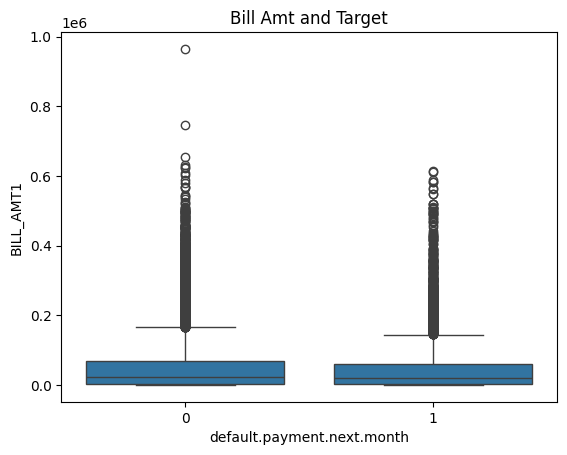

In [37]:
sns.boxplot(x=df[target],y=df['BILL_AMT1'],data=df)
plt.title('Bill Amt and Target')
plt.show()

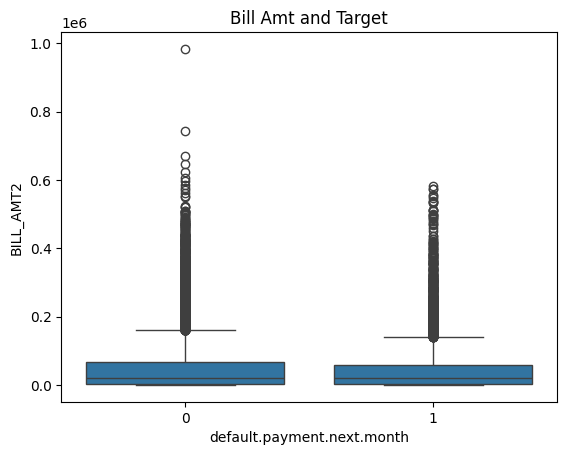

In [38]:
sns.boxplot(x=df[target],y=df['BILL_AMT2'],data=df)
plt.title('Bill Amt and Target')
plt.show()

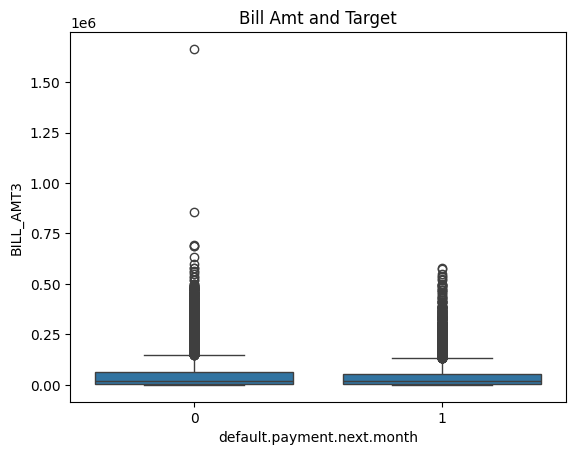

In [39]:
sns.boxplot(x=df[target],y=df['BILL_AMT3'],data=df)
plt.title('Bill Amt and Target')
plt.show()

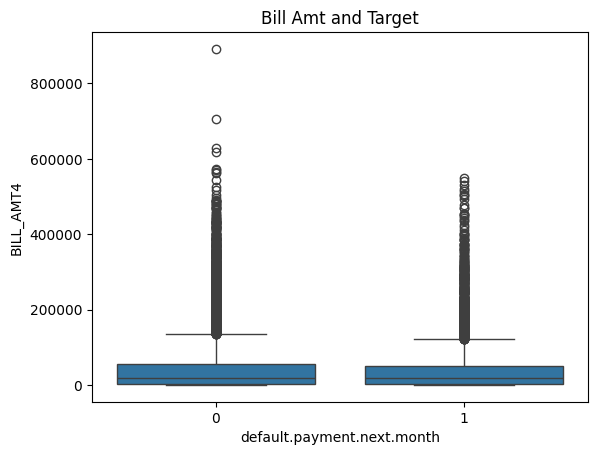

In [40]:
sns.boxplot(x=df[target],y=df['BILL_AMT4'],data=df)
plt.title('Bill Amt and Target')
plt.show()

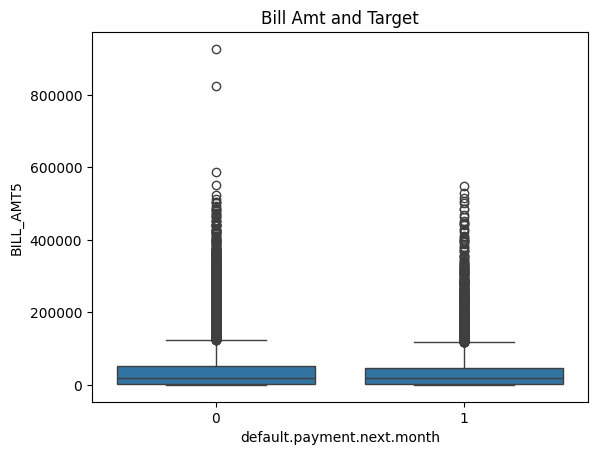

In [41]:
sns.boxplot(x=df[target],y=df['BILL_AMT5'],data=df)
plt.title('Bill Amt and Target')
plt.show()

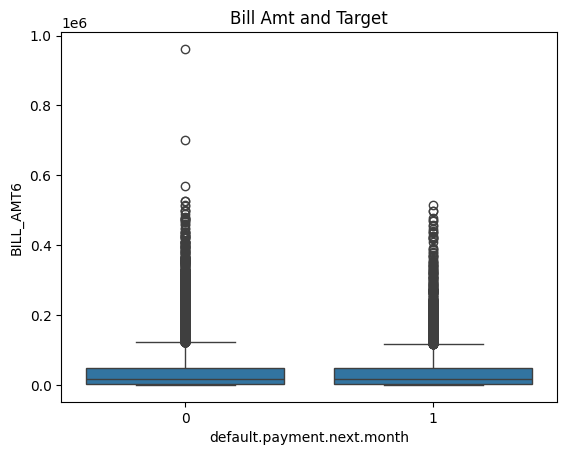

In [42]:
sns.boxplot(x=df[target],y=df['BILL_AMT6'],data=df)
plt.title('Bill Amt and Target')
plt.show()

In [43]:
def cap_upper(df,feature,limit):
    percentile_limit=df[feature].quantile(limit)
    df.loc[df[feature]>=percentile_limit,feature]=percentile_limit
    return df[feature]
# percentile-based capping func for all the feature

In [44]:
for i in range(1,7):
    feature='BILL_AMT'+str(i)
    df[feature]=cap_upper(df,feature,limit=0.95)
# Bill amount fix

In [45]:
def boxplot(feature):
    sns.boxplot(x=df[target],y=df[feature],data=df)
    plt.title(f"{feature} and Target")
    plt.show()

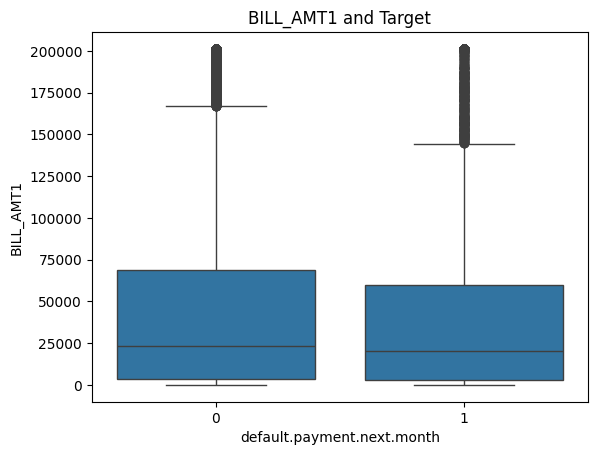

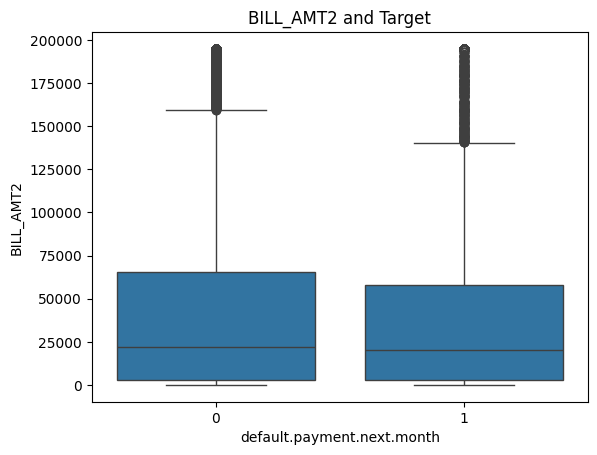

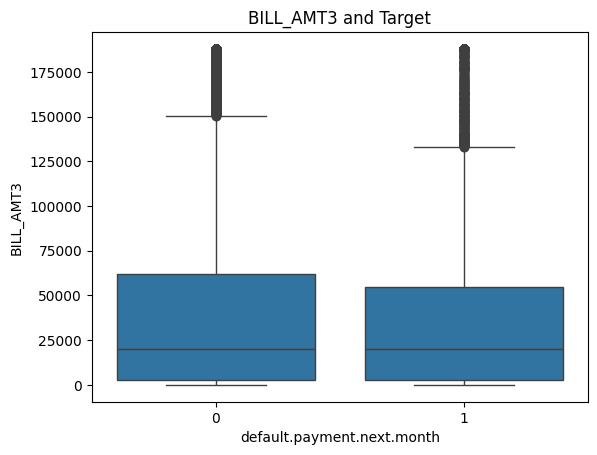

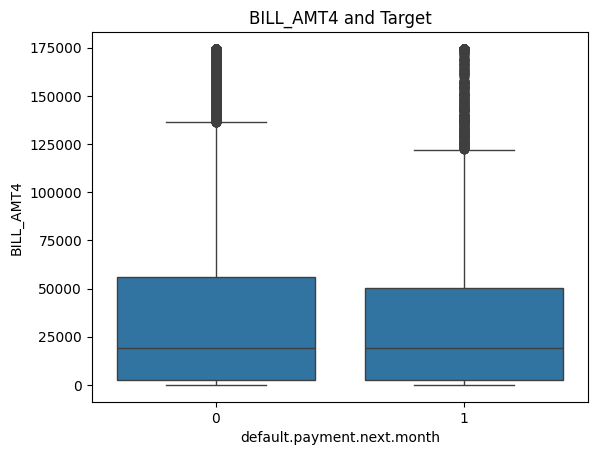

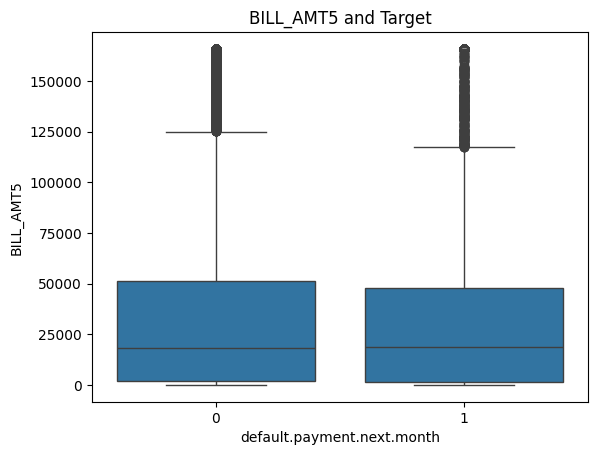

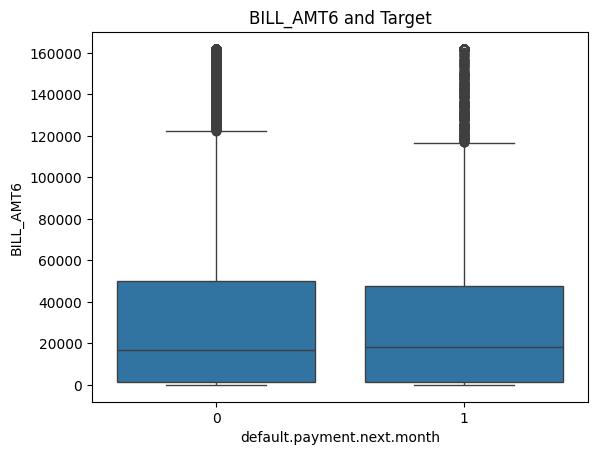

In [46]:
for feature in ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']:
    boxplot(feature)

In [47]:
df[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].describe(percentiles=[0.25,0.5,0.75,0.8,0.85,0.9,0.95,0.98])

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
80%,6192.200000,6.000000e+03,5284.00000,5000.000000,5000.000000,5000.000000
85%,8000.000000,7.956150e+03,7000.00000,6300.000000,6271.300000,6200.000000
90%,10300.000000,1.040110e+04,10000.00000,9570.600000,9500.000000,9600.000000


In [48]:
def outelierplot(feature):
    sns.boxplot(x=df[target],y=df[feature],data=df)
    plt.title(f'{feature} and Target Before Outlier Treatment')
    plt.show()

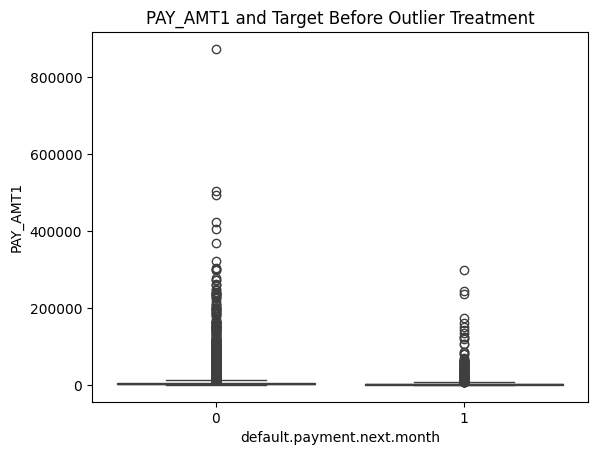

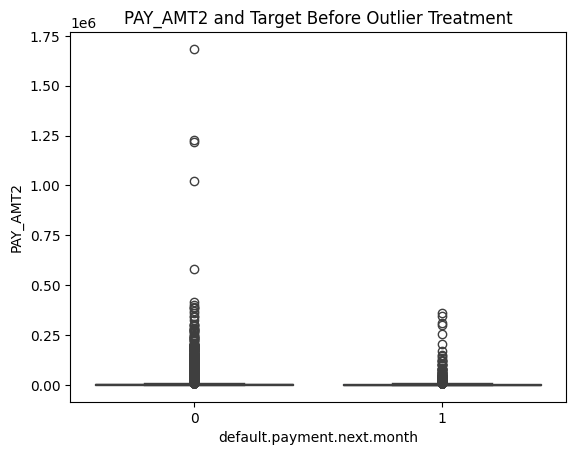

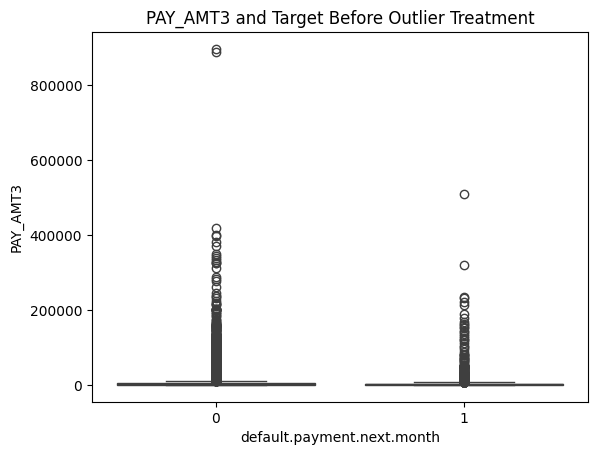

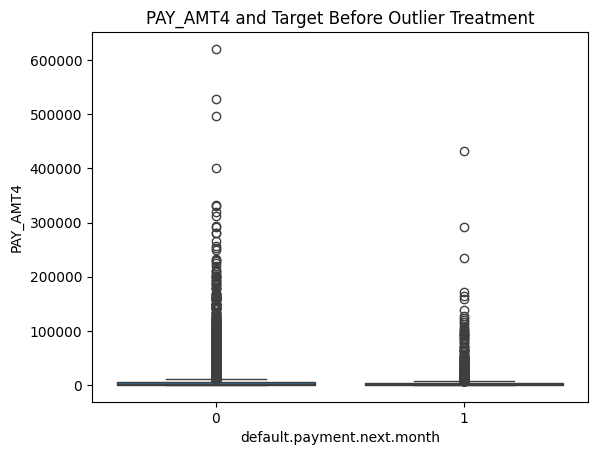

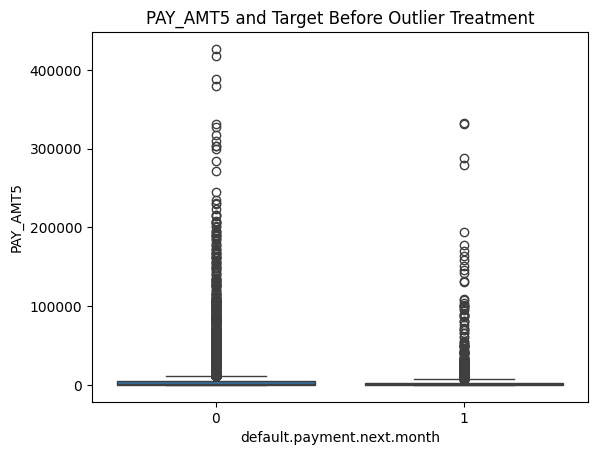

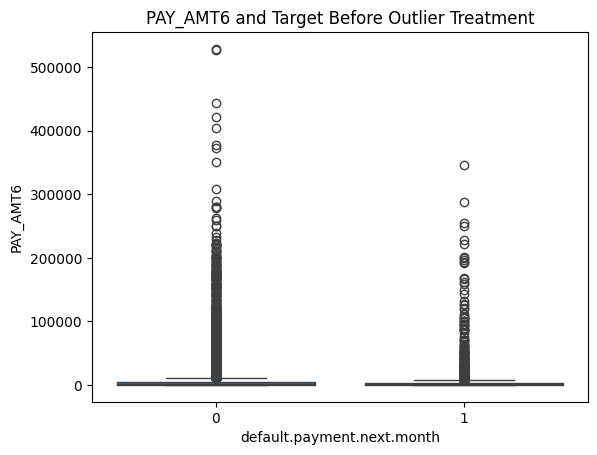

In [49]:
for f in ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']:
    outelierplot(f)

In [50]:
for i in range(1,7):
    feature='PAY_AMT'+str(i)
    df[feature]=cap_upper(df,feature,limit=0.90)

In [51]:
def treatment(feature):
    sns.boxplot(x=df[target],y=df[feature],data=df)
    plt.title(f'{feature} and Target After Outlier Treatment')
    plt.show()

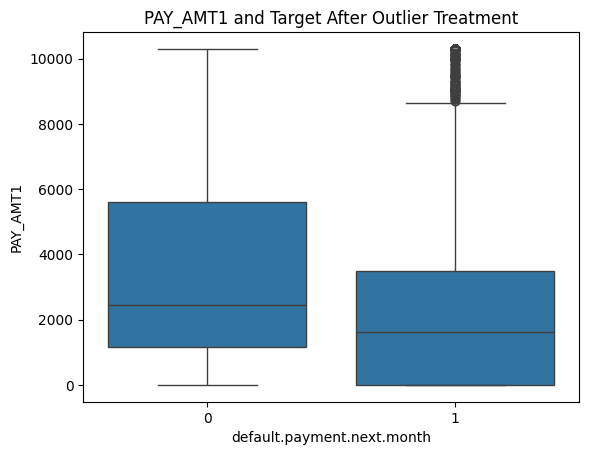

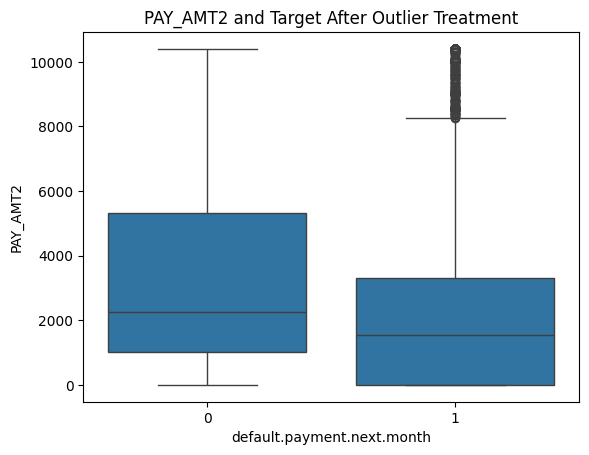

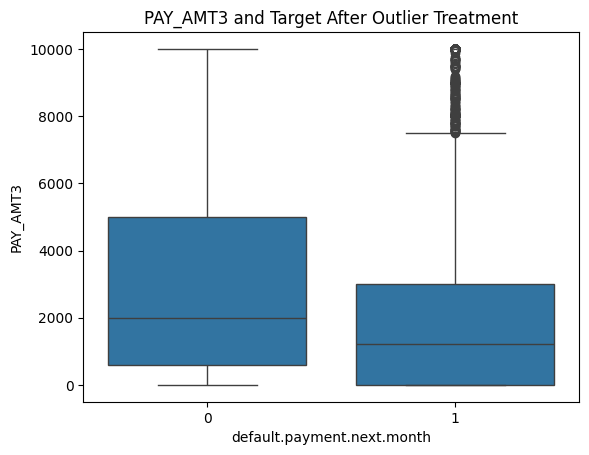

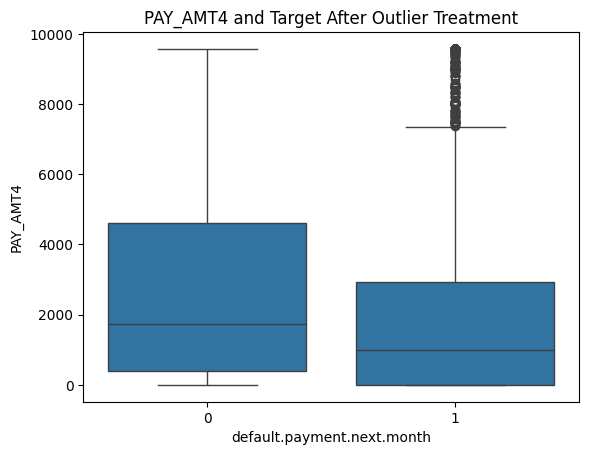

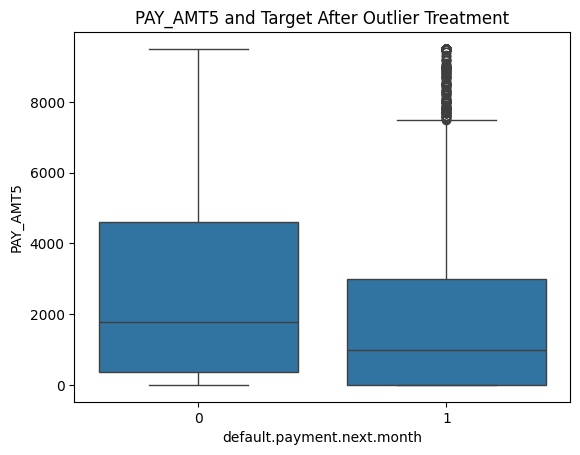

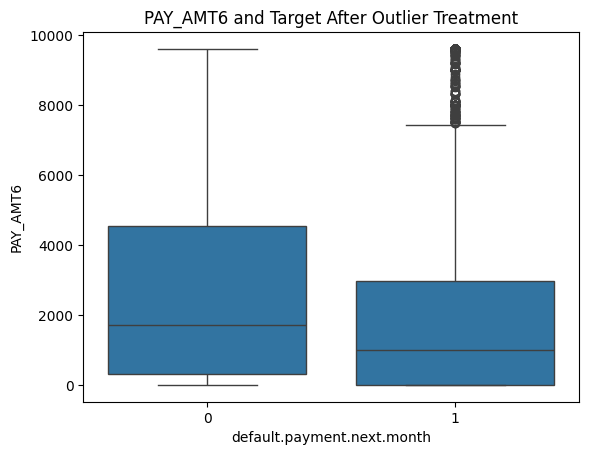

In [52]:
for f in ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']:
    treatment(f)

In [53]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,10401.1,10000.0,9000.0,689.0,679.0,0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  object 
 2   EDUCATION                   30000 non-null  object 
 3   MARRIAGE                    30000 non-null  object 
 4   AGE                         30000 non-null  int64  
 5   PAY_1                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [55]:
# converting data types

In [56]:
df[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','SEX','MARRIAGE','EDUCATION']]=df[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','SEX','MARRIAGE','EDUCATION']].astype('category')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   30000 non-null  float64 
 1   SEX                         30000 non-null  category
 2   EDUCATION                   30000 non-null  category
 3   MARRIAGE                    30000 non-null  category
 4   AGE                         30000 non-null  int64   
 5   PAY_1                       30000 non-null  category
 6   PAY_2                       30000 non-null  category
 7   PAY_3                       30000 non-null  category
 8   PAY_4                       30000 non-null  category
 9   PAY_5                       30000 non-null  category
 10  PAY_6                       30000 non-null  category
 11  BILL_AMT1                   30000 non-null  float64 
 12  BILL_AMT2                   30000 non-null  float64 
 13  BILL_AMT3       

In [58]:
df[['LIMIT_BAL','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']]=df[['LIMIT_BAL','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].astype('int')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   30000 non-null  int64   
 1   SEX                         30000 non-null  category
 2   EDUCATION                   30000 non-null  category
 3   MARRIAGE                    30000 non-null  category
 4   AGE                         30000 non-null  int64   
 5   PAY_1                       30000 non-null  category
 6   PAY_2                       30000 non-null  category
 7   PAY_3                       30000 non-null  category
 8   PAY_4                       30000 non-null  category
 9   PAY_5                       30000 non-null  category
 10  PAY_6                       30000 non-null  category
 11  BILL_AMT1                   30000 non-null  int64   
 12  BILL_AMT2                   30000 non-null  int64   
 13  BILL_AMT3       

In [60]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000,female,university,married,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,female,university,single,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,female,university,single,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,female,university,married,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,male,university,married,57,-1,0,-1,0,0,...,20940,19146,19131,2000,10401,10000,9000,689,679,0


In [61]:
df.duplicated().sum()

np.int64(55)

In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.duplicated().sum()

np.int64(0)

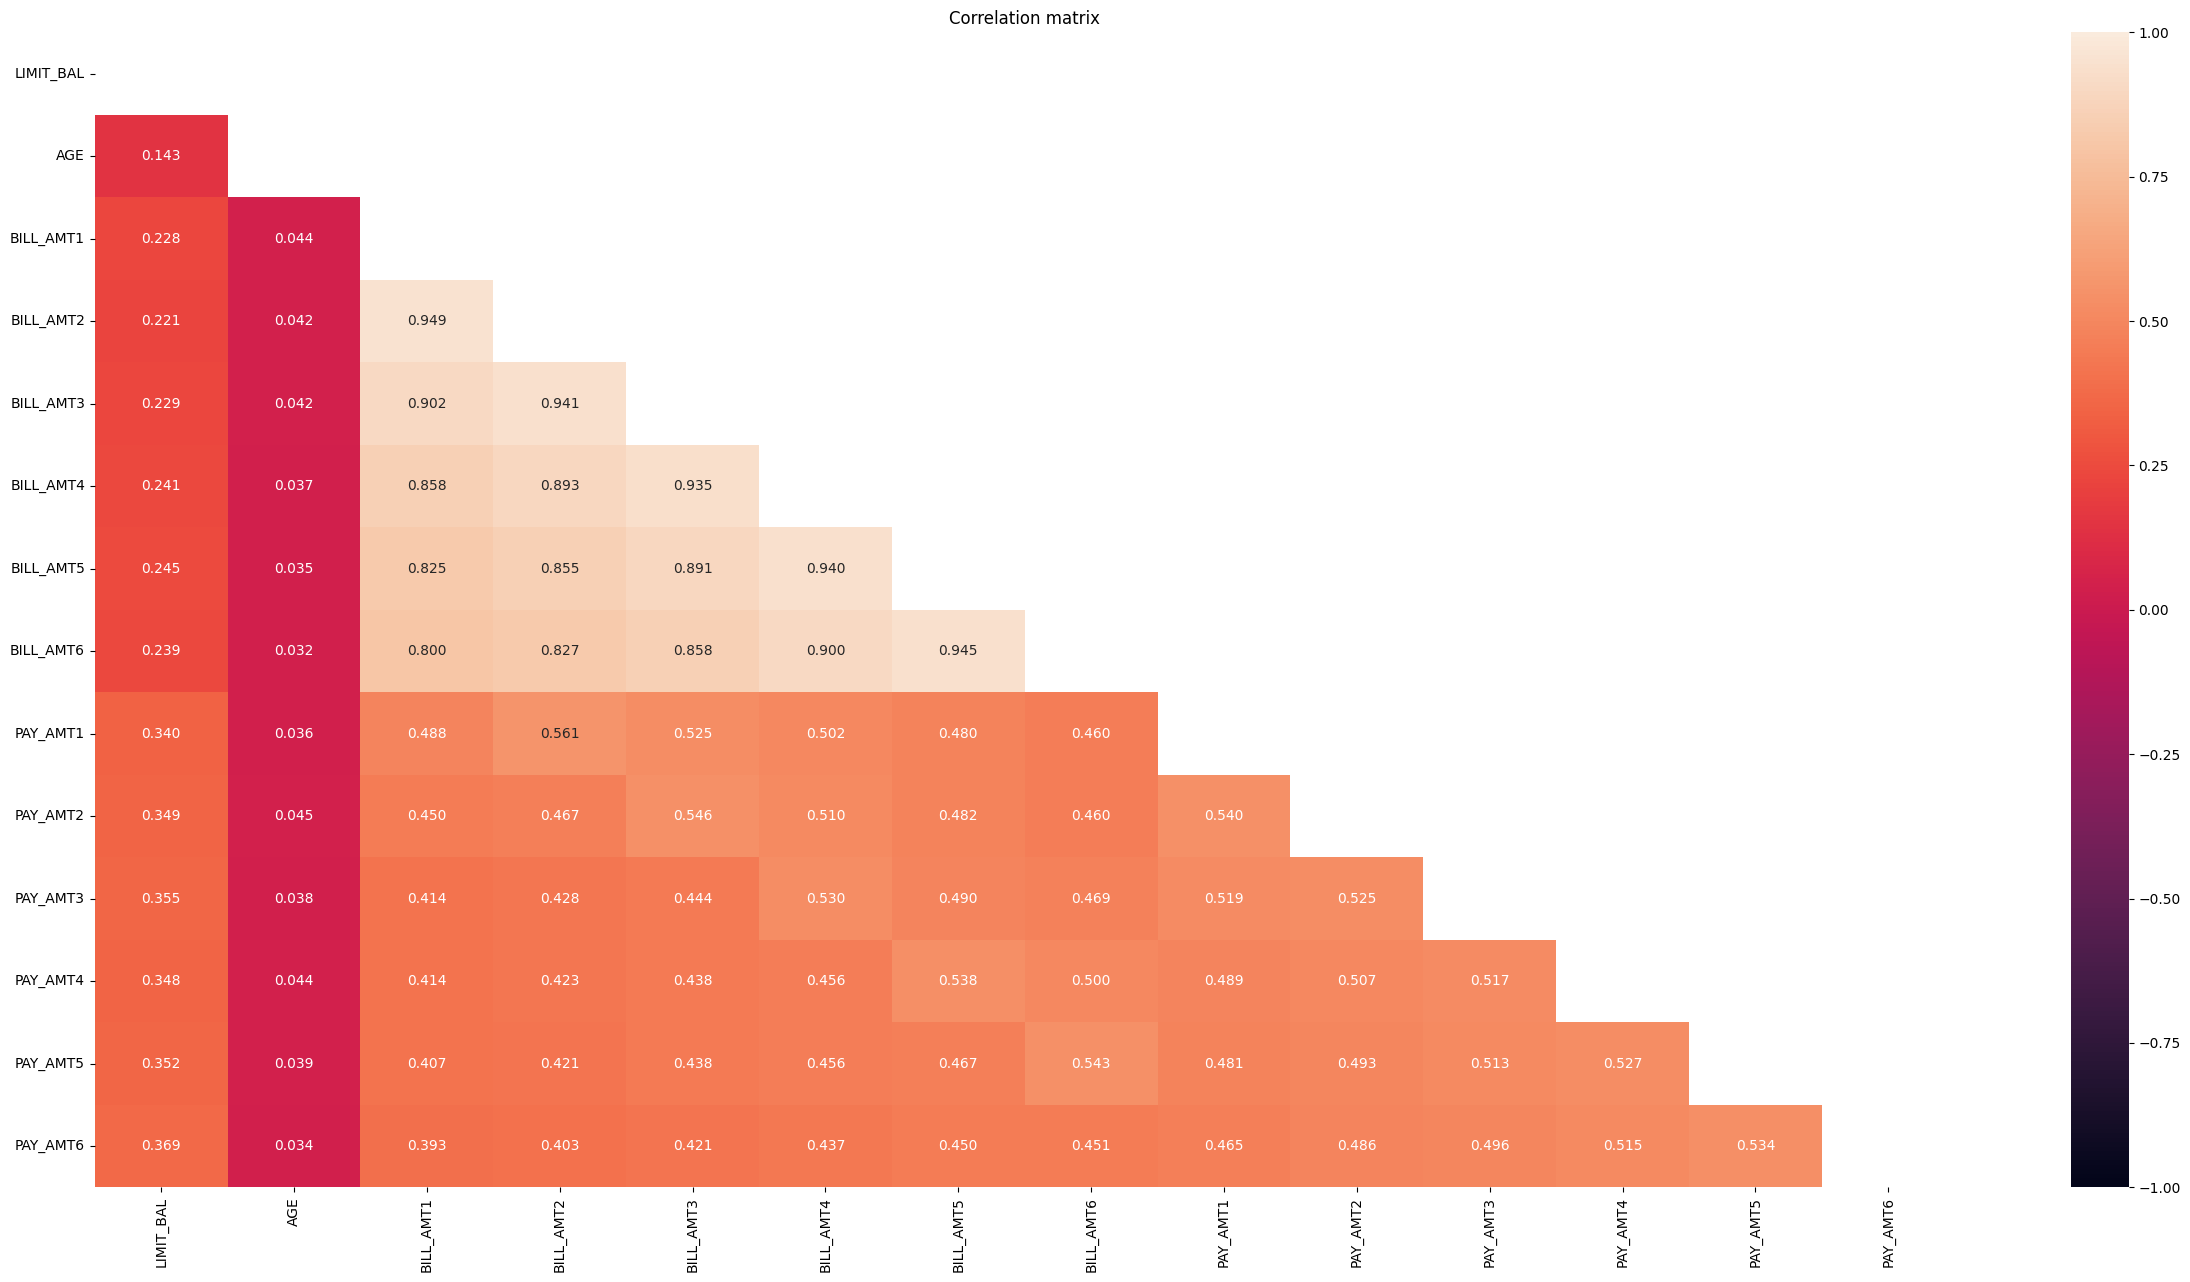

In [64]:
# Correlation Matrix
plt.figure(figsize=(30,15))
num_df = df.select_dtypes(include=[np.number]).drop(columns=target)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation matrix')
plt.show()

In [65]:
df.to_csv('../../../../resource/source/cleaned_credit_defaulter.csv', index=False)
# saving cleansed dataset for model training

# Model Testing to pick Best Model out of available model

In [88]:
model_df = pd.read_csv('../../../../resource/source/cleaned_credit_defaulter.csv')

In [89]:
model_df[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','SEX','MARRIAGE','EDUCATION']]=model_df[['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','SEX','MARRIAGE','EDUCATION']].astype('category')

In [90]:
cat_features = model_df.select_dtypes(include=['object','category']).columns.tolist()

In [91]:
num_features = model_df.drop('default.payment.next.month',axis=1).select_dtypes(include = ['int64','float64']).columns.tolist()

In [92]:
print(cat_features)

['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [93]:
print(num_features)

['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


# Model Building

In [94]:
target= 'default.payment.next.month'

In [95]:
X = model_df.drop(columns=[target])
y = model_df[target]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [97]:
y_train

22396    0
5190     1
17453    1
23702    0
23930    1
        ..
28206    0
13858    0
2792     1
25162    1
3494     0
Name: default.payment.next.month, Length: 23956, dtype: int64

In [98]:
X_train.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [99]:
models = {
    "Logistic": LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(max_depth=2,gamma=10,colsample_bytree=0.4),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
}


In [100]:
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=False
)

cat_feature_indices = [X.columns.get_loc(c) for c in cat_features]

In [101]:
# Convert categorical columns to object
for col in cat_features:
    X_train[col] = X_train[col].astype('object')
    X_test[col] = X_test[col].astype('object')

In [102]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=10):
        self.smoothing = smoothing
        self.mapping = {}
        self.global_mean = None

    def fit(self, X, y):
        self.global_mean = y.mean()
        for col in X.columns:
            stats = y.groupby(X[col]).agg(['mean', 'count'])
            smooth = (
                stats['mean'] * stats['count']
                + self.global_mean * self.smoothing
            ) / (stats['count'] + self.smoothing)
            self.mapping[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].map(self.mapping[col]).fillna(self.global_mean)
        return X

te_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', TargetEncoder(smoothing=10), cat_features)
    ]
)

# Target Encoding

In [103]:
ohe_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)
#OneHot Encoding

In [104]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
import pandas as pd

results = []

for name, model in models.items():
    if name in ['RandomForest','Logistic']:
        pipe = Pipeline([('prep', ohe_preprocessor),('model', model)])
    else:
        #name in ['GradientBoosting','XGBoost','LightGBM']:
        pipe = Pipeline([('prep', te_preprocessor),('model', model) ])
    
    pipe.fit(X_train, y_train)
    test_y_proba = pipe.predict_proba(X_test)[:, 1]
    train_y_proba = pipe.predict_proba(X_train)[:, 1]

    results.append({
        "Model": name,
        "test_ROC_AUC": roc_auc_score(y_test, test_y_proba),
        "train_ROC_AUC": roc_auc_score(y_train, train_y_proba),
    })

results_df = pd.DataFrame(results).sort_values("test_ROC_AUC", ascending=False)
results_df

[LightGBM] [Info] Number of positive: 5304, number of negative: 18652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002797 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3237
[LightGBM] [Info] Number of data points in the train set: 23956, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221406 -> initscore=-1.257492
[LightGBM] [Info] Start training from score -1.257492


,Model,test_ROC_AUC,train_ROC_AUC
2,GradientBoosting,0.774155,0.818173
4,LightGBM,0.768775,0.909439
1,RandomForest,0.768218,0.818746
3,XGBoost,0.761950,0.786730
0,Logistic,0.760594,0.780186


In [105]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
import pandas as pd

results = []

for name, model in models.items():
    pipe = Pipeline([('prep', te_preprocessor),('model', model) ])
    pipe.fit(X_train, y_train)
    test_y_proba = pipe.predict_proba(X_test)[:, 1]
    train_y_proba = pipe.predict_proba(X_train)[:, 1]

    results.append({
        "Model": name,
        "test_ROC_AUC": roc_auc_score(y_test, test_y_proba),
        "train_ROC_AUC": roc_auc_score(y_train, train_y_proba),
    })

results_df = pd.DataFrame(results).sort_values("test_ROC_AUC", ascending=False)
results_df

[LightGBM] [Info] Number of positive: 5304, number of negative: 18652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3237
[LightGBM] [Info] Number of data points in the train set: 23956, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221406 -> initscore=-1.257492
[LightGBM] [Info] Start training from score -1.257492


,Model,test_ROC_AUC,train_ROC_AUC
2,GradientBoosting,0.774155,0.818173
1,RandomForest,0.769383,0.829285
4,LightGBM,0.768775,0.909439
3,XGBoost,0.761950,0.786730
0,Logistic,0.755192,0.774758


In [106]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
import pandas as pd

results = []

for name, model in models.items():
    pipe = Pipeline([('prep', ohe_preprocessor),('model', model)])
    pipe.fit(X_train, y_train)
    test_y_proba = pipe.predict_proba(X_test)[:, 1]
    train_y_proba = pipe.predict_proba(X_train)[:, 1]

    results.append({
        "Model": name,
        "test_ROC_AUC": roc_auc_score(y_test, test_y_proba),
        "train_ROC_AUC": roc_auc_score(y_train, train_y_proba),
    })

results_df = pd.DataFrame(results).sort_values("test_ROC_AUC", ascending=False)
results_df

[LightGBM] [Info] Number of positive: 5304, number of negative: 18652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3247
[LightGBM] [Info] Number of data points in the train set: 23956, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221406 -> initscore=-1.257492
[LightGBM] [Info] Start training from score -1.257492


,Model,test_ROC_AUC,train_ROC_AUC
2,GradientBoosting,0.771954,0.815003
4,LightGBM,0.768942,0.906654
1,RandomForest,0.768218,0.818746
3,XGBoost,0.764263,0.786254
0,Logistic,0.760594,0.780186


In [107]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
import pandas as pd

results = []

for name, model in models.items():
    if name in ['RandomForest','Logistic']:
        pipe = Pipeline([('prep', te_preprocessor),('model', model) ])
    else:
        #name in ['GradientBoosting','XGBoost','LightGBM']:
        pipe = Pipeline([('prep', ohe_preprocessor),('model', model)])
    
    pipe.fit(X_train, y_train)
    test_y_proba = pipe.predict_proba(X_test)[:, 1]
    train_y_proba = pipe.predict_proba(X_train)[:, 1]

    results.append({
        "Model": name,
        "test_ROC_AUC": roc_auc_score(y_test, test_y_proba),
        "train_ROC_AUC": roc_auc_score(y_train, train_y_proba),
    })

results_df = pd.DataFrame(results).sort_values("test_ROC_AUC", ascending=False)
results_df

[LightGBM] [Info] Number of positive: 5304, number of negative: 18652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3247
[LightGBM] [Info] Number of data points in the train set: 23956, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221406 -> initscore=-1.257492
[LightGBM] [Info] Start training from score -1.257492


,Model,test_ROC_AUC,train_ROC_AUC
2,GradientBoosting,0.771954,0.815003
1,RandomForest,0.769383,0.829285
4,LightGBM,0.768942,0.906654
3,XGBoost,0.764263,0.786254
0,Logistic,0.755192,0.774758


# Final Conclusion

### GradientBoost outperform all other model, hence considering Greaidentboost as final model